## **Messwerte**

In [1]:
import numpy as np

g = 9.80665 #Erdbeschleunigung

m = 0.1 #Masse des Schwingkörpers in kg
m_Fehler = 0.1


d = 1 #Durchmesser des Schwingrohrs in m
d_Fehler = 0.1 #Messfehler für d


p_Umgebung = 1 #Umgebungsdruck in Pa
p_Umgebung_Fehler = 0.1

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Messungen zu Argon

V_Argon = np.array([1 , 2 , 3 , 4 , 5 , 6 , 7 , 8 , 9 , 10 ]) # Die 10 Gesamtvolumen des Gefäßes in m^3

V_Fehler = 1 #TODO

T_Argon_values = np.array([[ 11 , 12 , 13 ] , [ 21 , 22 , 23 ] , [ 31 , 32 , 33 ] , [ 41 , 42 , 43 ] , [ 51 , 52 , 53 ] , [ 61 , 62 , 63 ] , [ 71 , 72 , 73 ] , [ 81 , 82 , 83 ] , [ 91 , 92 , 93 ] , [ 101 , 102 , 103 ] ])

T_Argon_Messfehler = 1 #TODO

T_Argon = np.mean(T_Argon_values, axis = 1)
T_Argon_statFehler = np.std(T_Argon_values, axis = 1, ddof = 1) / np.sqrt(3)
T_Argon_Fehler = np.sqrt(T_Argon_statFehler**2 + T_Argon_Messfehler**2)


"""-----------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Messungen zu Stickstoff

V_Stickstoff = np.array([1 , 2 , 3 , 4 , 5 , 6 , 7 , 8 , 9 , 10 ]) # Die 10 Gesamtvolumen des Gefäßes in m^3

V_Fehler = 1 #TODO

T_Stickstoff_values = np.array([[ 11 , 12 , 13 ] , [ 21 , 22 , 23 ] , [ 31 , 32 , 33 ] , [ 41 , 42 , 43 ] , [ 51 , 52 , 53 ] , [ 61 , 62 , 63 ] , [ 71 , 72 , 73 ] , [ 81 , 82 , 83 ] , [ 91 , 92 , 93 ] , [ 101 , 102 , 103 ] ])

T_Stickstoff_Messfehler = 1 #TODO

T_Stickstoff = np.mean(T_Stickstoff_values, axis = 1)
T_Stickstoff_statFehler = np.std(T_Stickstoff_values, axis = 1, ddof = 1) / np.sqrt(3)
T_Stickstoff_Fehler = np.sqrt(T_Stickstoff_statFehler**2 + T_Stickstoff_Messfehler**2)


"""-----------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Messungen zu CO2

V_CO2 = np.array([1 , 2 , 3 , 4 , 5 , 6 , 7 , 8 , 9 , 10 ]) # Die 10 Gesamtvolumen des Gefäßes in m^3

V_Fehler = 1 #TODO

T_CO2_values = np.array([[ 11 , 12 , 13 ] , [ 21 , 22 , 23 ] , [ 31 , 32 , 33 ] , [ 41 , 42 , 43 ] , [ 51 , 52 , 53 ] , [ 61 , 62 , 63 ] , [ 71 , 72 , 73 ] , [ 81 , 82 , 83 ] , [ 91 , 92 , 93 ] , [ 101 , 102 , 103 ] ])

T_CO2_Messfehler = 1 #TODO

T_CO2 = np.mean(T_CO2_values, axis = 1)
T_CO2_statFehler = np.std(T_CO2_values, axis = 1, ddof = 1) / np.sqrt(3)
T_CO2_Fehler = np.sqrt(T_CO2_statFehler**2 + T_CO2_Messfehler**2)

## **Lineare Regression**

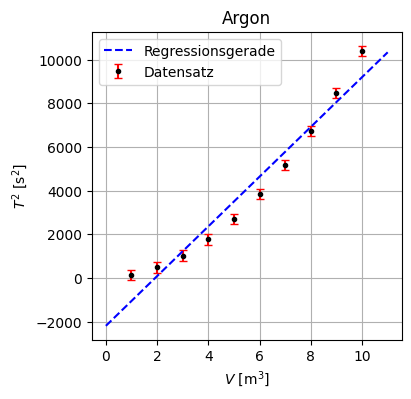

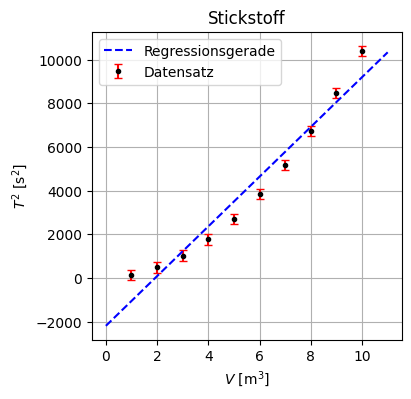

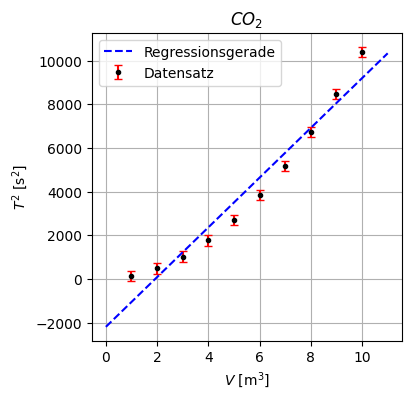

In [2]:
import matplotlib.pyplot as plt
import scipy
import sympy
from Skripte.Fehlerfortpflanzung import Gaußfehler

Tp = sympy.symbols("T")
expr0 = Tp**2
Variablen_0 = np.array([Tp])

def f(x,k,a):
    return k*x + a #Fit Funktion

fig, ax1 = plt.subplots(1,1, figsize = (4,4))
fig, ax2 = plt.subplots(1,1, figsize = (4,4))
fig, ax3 = plt.subplots(1,1, figsize = (4,4))

#Argon
T_Argon_quad = T_Argon**2

T_Argon_quad_Fehler = np.zeros(10, dtype = float)

for i in range(0, len(T_Argon_quad)):
    T_Argon_quad_Fehler = Gaußfehler(expr0, Variablen_0, np.array([T_Argon[i]]), np.array([T_Argon_Fehler[i]]))

coefficients, pcov = scipy.optimize.curve_fit(f, V_Argon, T_Argon_quad, sigma= T_Argon_quad_Fehler, absolute_sigma= True)

k_Argon = coefficients[0] #Steigung der Regressionsgeraden
k_Argon_Fehler = np.sqrt(pcov[0,0])

ax1.errorbar(V_Argon, T_Argon_quad, yerr = T_Argon_quad_Fehler, fmt = "o", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

xwerte = np.linspace(0, np.max(V_Argon)*1.1, 500)
ax1.plot(xwerte, k_Argon*xwerte + coefficients[1], color = "blue", linestyle = "--", label = "Regressionsgerade")

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Stickstoff

T_Stickstoff_quad = T_Stickstoff**2

T_Stickstoff_quad_Fehler = np.zeros(10, dtype = float)

for i in range(0, len(T_Stickstoff_quad)):
    T_Stickstoff_quad_Fehler = Gaußfehler(expr0, Variablen_0, np.array([T_Stickstoff[i]]), np.array([T_Stickstoff_Fehler[i]]))

coefficients, pcov = scipy.optimize.curve_fit(f, V_Stickstoff, T_Stickstoff_quad, sigma= T_Stickstoff_quad_Fehler, absolute_sigma= True)

k_Stickstoff = coefficients[0] #Steigung der Regressionsgeraden
k_Stickstoff_Fehler = np.sqrt(pcov[0,0])

ax2.errorbar(V_Stickstoff, T_Stickstoff_quad, yerr = T_Stickstoff_quad_Fehler, fmt = "o", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

xwerte = np.linspace(0, np.max(V_Stickstoff)*1.1, 500)
ax2.plot(xwerte, k_Stickstoff*xwerte + coefficients[1], color = "blue", linestyle = "--", label = "Regressionsgerade")

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#CO2

T_CO2_quad = T_CO2**2

T_CO2_quad_Fehler = np.zeros(10, dtype = float)

for i in range(0, len(T_CO2_quad)):
    T_CO2_quad_Fehler = Gaußfehler(expr0, Variablen_0, np.array([T_CO2[i]]), np.array([T_CO2_Fehler[i]]))

coefficients, pcov = scipy.optimize.curve_fit(f, V_CO2, T_CO2_quad, sigma= T_CO2_quad_Fehler, absolute_sigma= True)

k_CO2 = coefficients[0] #Steigung der Regressionsgeraden
k_CO2_Fehler = np.sqrt(pcov[0,0])

ax3.errorbar(V_CO2, T_CO2_quad, yerr = T_CO2_quad_Fehler, fmt = "o", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

xwerte = np.linspace(0, np.max(V_CO2)*1.1, 500)
ax3.plot(xwerte, k_CO2*xwerte + coefficients[1], color = "blue", linestyle = "--", label = "Regressionsgerade")

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------------"""

ax1.set_xlabel("$V~[\\mathrm{m^3}]$")
ax1.set_ylabel("$T^2~[\\mathrm{s^2]}$")
ax1.grid(True)
ax1.set_title("Argon")
ax1.legend()
ax2.set_xlabel("$V~[\\mathrm{m^3}]$")
ax2.set_ylabel("$T^2~[\\mathrm{s^2]}$")
ax2.grid(True)
ax2.set_title("Stickstoff")
ax2.legend()
ax3.set_xlabel("$V~[\\mathrm{m^3}]$")
ax3.set_ylabel("$T^2~[\\mathrm{s^2]}$")
ax3.grid(True)
ax3.set_title("$CO_{2}$")
ax3.legend()



## **Berechnung der Adiabatenexponenten**

In [3]:

A = np.pi*(d/2)**2 #Querschnittsfläche des Schwingers in m^2

dp = sympy.symbols("d")
expr2 = sympy.pi * (dp/2)**2
display(expr2)

A_Fehler = Gaußfehler(expr2, np.array([dp]), np.array([d]), np.array([d_Fehler]))



p_Ruhe = p_Umgebung + m*g/A

pU, mp, Ap = sympy.symbols("p_0, m, A")
expr2 = pU + mp*g/Ap
display(expr2)

p_Ruhe_Fehler = Gaußfehler(expr2, np.array([pU, mp, Ap]), np.array([p_Umgebung, m, A]), np.array([p_Umgebung_Fehler, m_Fehler, A_Fehler]))



mp, kp, pR, Ap = sympy.symbols("m, k , p_Ruhe , A ")
expr3 = (4*sympy.pi**2*mp) / (kp*pR*Ap**2)
display(expr3)
Variablen_3 = np.array([mp, kp, pR, Ap])

kappa_Argon = (4*np.pi**2*m) / (k_Argon*p_Ruhe*A**2)
kappa_Argon_Fehler = Gaußfehler(expr3, Variablen_3, np.array([m, k_Argon, p_Ruhe, A]), np.array([m_Fehler, k_Argon_Fehler, p_Ruhe_Fehler, A_Fehler]))

kappa_Stickstoff = (4*np.pi**2*m) / (k_Stickstoff*p_Ruhe*A**2)
kappa_Stickstoff_Fehler = Gaußfehler(expr3, Variablen_3, np.array([m, k_Stickstoff, p_Ruhe, A]), np.array([m_Fehler, k_Stickstoff_Fehler, p_Ruhe_Fehler, A_Fehler]))

kappa_CO2 = (4*np.pi**2*m) / (k_CO2*p_Ruhe*A**2)
kappa_CO2_Fehler = Gaußfehler(expr3, Variablen_3, np.array([m, k_CO2, p_Ruhe, A]), np.array([m_Fehler, k_CO2_Fehler, p_Ruhe_Fehler, A_Fehler]))

print(f"\n kappa für Argon: kappa = {kappa_Argon} +/- {kappa_Argon_Fehler}")
print(f"\n kappa für Stickstoff: kappa = {kappa_Stickstoff} +/- {kappa_Stickstoff_Fehler}")
print(f"\n kappa für Co2: kappa = {kappa_CO2} +/- {kappa_CO2_Fehler}")


pi*d**2/4

p_0 + 9.80665*m/A

4*pi**2*m/(A**2*k*p_Ruhe)


 kappa für Argon: kappa = 0.0024966563693450666 +/- 0.003040562711781736

 kappa für Stickstoff: kappa = 0.0024966563693450666 +/- 0.003040562711781736

 kappa für Co2: kappa = 0.0024966563693450666 +/- 0.003040562711781736
